# Notebook 04 — L3 NiO full d⁸ + ligand bath ADAPT-VQE

Phase 4 deliverable. 18-qubit tapered SIAM, operator-ADAPT-VQE, 4-seed multistart, 6 validation layers, 2 figures.

Reference spec: `docs/superpowers/specs/2026-05-26-siam-vqe-phase-4-l3-design.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
# Bootstrap: the editable install can point at a different siam_vqe
# checkout (e.g. the primary tree). Prepend this worktree's package root
# so the notebook always imports the local L3 modules.
sys.path.insert(0, str(Path.cwd().parent.resolve()))
import json
import numpy as np
import matplotlib.pyplot as plt

from siam_vqe.hamiltonian_l3 import L3Params
from siam_vqe.reference_l3 import load_l3_reference, inspect_multiplets
from siam_vqe.analysis import plot_adapt_convergence, plot_l3_observables


## 1. Reference spectrum

Load the precomputed scipy-ED reference (committed at `data/nio_l3_reference.npz`) and inspect the low-lying spectrum to confirm a non-degenerate orbital singlet at the bottom of the (9,9) sector.

In [2]:
ref = load_l3_reference(Path('../data/nio_l3_reference.npz'))
print(f'Ground energy: {ref.ground_energy:.6f} eV')
for row in inspect_multiplets(ref):
    print(f"  state {row['index']}: E = {row['energy_eV']:.6f} eV, "
          f"gap = {row['gap_eV']:.6f} eV")
print()
print('ED reference observables:')
for k, v in ref.observables.items():
    print(f'  {k}: {v:.6f}')


Ground energy: 267.476996 eV
  state 0: E = 267.476996 eV, gap = 0.000000 eV
  state 1: E = 268.080023 eV, gap = 0.603027 eV
  state 2: E = 268.080023 eV, gap = 0.603027 eV
  state 3: E = 268.080023 eV, gap = 0.603027 eV
  state 4: E = 268.526757 eV, gap = 1.049761 eV
  state 5: E = 268.526757 eV, gap = 1.049761 eV
  state 6: E = 268.526757 eV, gap = 1.049761 eV
  state 7: E = 269.345631 eV, gap = 1.868635 eV
  state 8: E = 269.345631 eV, gap = 1.868635 eV
  state 9: E = 269.873025 eV, gap = 2.396029 eV

ED reference observables:
  n_d: 8.002005
  n_p: 9.997995
  n_d_3z2: 1.001002
  n_d_x2y2: 1.001002
  n_d_xz: 2.000000
  n_d_yz: 2.000000
  n_d_xy: 2.000000
  S2: 1.997494


## 2. Load production-run result

The CLI driver `scripts/run_l3_adapt.py --mode production --seeds 4` writes `notebooks/04_L3_vqe_result.json`. Re-running it here is expensive (~30-60 min); we just load the cached JSON.

In [3]:
with open('04_L3_vqe_result.json') as fh:
    result = json.load(fh)
print(f"Mode: {result['mode']}")
print(f"Seeds: {result['n_seeds']}")
print(f"Pool size: {result['pool_size']}")
print(f"Best energy: {result['final_energy']:.6f} eV")
print(f"ED reference: {ref.ground_energy:.6f} eV")
print(f"Abs error: {abs(result['final_energy'] - ref.ground_energy)*1000:.2f} meV")
print(f"Operators picked: {len(result['operators_picked'])} / max {result['config']['max_operators']}")
print(f"Converged reason: {result['converged_reason']}")
print(f"Wall time: {result['wall_time_seconds']:.0f} s")


Mode: production
Seeds: 4
Pool size: 99
Best energy: 267.476996 eV
ED reference: 267.476996 eV
Abs error: 0.00 meV
Operators picked: 7 / max 30
Converged reason: gradient
Wall time: 1543 s


## 3. Validation layers

In [4]:
for layer, payload in result['validation_layers'].items():
    status = 'PASS' if payload['pass'] else 'FAIL'
    print(f'  {layer}: {status}')
    for k, v in payload.items():
        if k == 'pass':
            continue
        if isinstance(v, (dict, list)):
            print(f'    {k}: {type(v).__name__}({len(v)})')
        else:
            print(f'    {k}: {v}')
    print()
print(f"Phase 4 pass = {result['phase4_pass']}")


  layer1_energy: PASS
    vqe_energy: 267.47699612485553
    ed_energy: 267.4769961247642
    abs_err_eV: 9.134737410931848e-11
    tolerance_eV: 0.05

  layer2_overlap: PASS
    overlap: 0.99999999999413
    mode: strict
    sector_leak: 0.0

  layer4_multistart: PASS
    mode: soft_cluster
    spread_eV: 3.0791030920808566
    warn: cluster-like behavior
    best_energy_eV: 267.47699612485553
    median_energy_eV: 269.01654767090065
    worst_energy_eV: 270.5560992169364

  layer5_observables: PASS
    details: dict(8)

  layer6_adapt_trace: PASS
    violations: list(0)
    n_operator_steps: 7

Phase 4 pass = True


## 4. Figure: ADAPT convergence trace

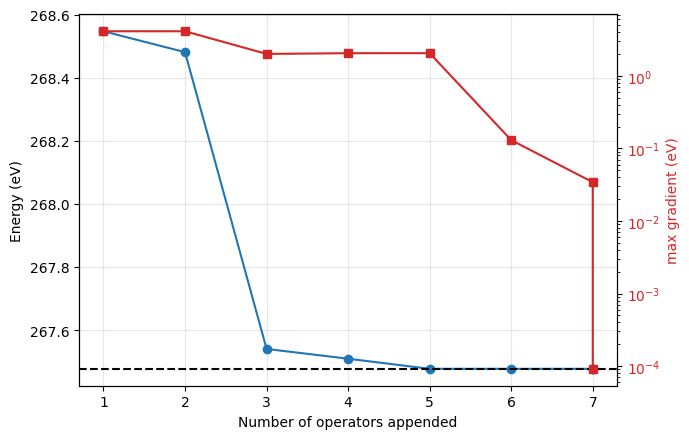

In [5]:
ax = plot_adapt_convergence(result['adapt_trace'],
                             ed_reference=ref.ground_energy,
                             output_path='../figures/04_adapt_convergence.pdf')
plt.show()


## 5. Figure: VQE vs ED observables

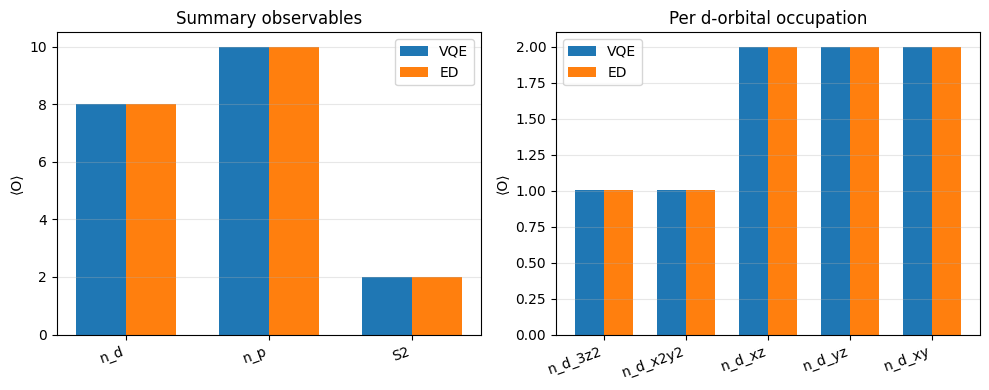

In [6]:
ax = plot_l3_observables(result['vqe_observables'],
                          result['ed_observables'],
                          output_path='../figures/04_l3_observables.pdf')
plt.show()


## 6. Closeout summary

If `phase4_pass = True`: Phase 4 complete.

If `phase4_pass = False`: read the layer-by-layer payload. Energy gap > 50 meV with `max_operators` hit is a research finding (spec §6.2 honesty clause), NOT a bug — report final gap, dropped-gradient magnitudes, and what the pool didn't cover.